# 常用激活函数对比

激活函数为神经网络引入**非线性**，使其能拟合复杂关系。没有激活函数，多层网络等价于一层线性变换。下面汇总本节涉及的各个函数（顺序与下文一致）。

## 总览表

| 函数 | 公式 | 输出范围 | 特点 | 使用场景 | 原因 / 缺点 |
|------|------|----------|------|----------|-------------|
| **sigmoid** | $\dfrac{1}{1+e^{-x}}$ | $(0,1)$ | 平滑、可导、可解释为概率 | 二分类输出层、门控（LSTM/GRU） | 两端梯度趋 0（**梯度消失**）；输出非零中心；含指数较慢 |
| **阶跃函数** | $h(x)=\begin{cases}1&x>0\\0&x\le0\end{cases}$ | $\{0,1\}$ | 不连续、不可导 | 早期感知机、理论说明 | 不可导无法做梯度下降，实际几乎不用 |
| **ReLU** | $\max(0,x)$ | $[0,+\infty)$ | 计算极快、缓解梯度消失、稀疏激活 | **隐藏层默认首选**（CNN/MLP） | 负区间输出恒 0，可能**神经元死亡**；输出非零中心 |
| **Leaky ReLU** | $\begin{cases}x&x>0\\\alpha x&x\le0\end{cases}$ | $(-\infty,+\infty)$ | 负区间给小斜率 | ReLU 出现死亡神经元时 | 引入超参 $\alpha$，效果不总是更好 |
| **ELU** | $\begin{cases}x&x>0\\\alpha(e^x-1)&x\le0\end{cases}$ | $(-\alpha,+\infty)$ | 负区间平滑、均值接近 0 | 想要更平滑、更快收敛 | 含指数，计算比 ReLU 慢 |
| **GELU** | $x\cdot\Phi(x)$ | $\approx[-0.17,+\infty)$ | 平滑、按概率"软门控" | **Transformer 标配**（BERT/GPT） | 计算较复杂（常用近似式） |
| **Swish / SiLU** | $x\cdot\sigma(x)$ | $\approx[-0.28,+\infty)$ | 平滑、非单调 | 深层网络（EfficientNet 等） | 计算比 ReLU 慢 |
| **softmax** | $\dfrac{e^{x_i}}{\sum_j e^{x_j}}$ | $(0,1)$ 且和为 1 | 输出归一化为概率分布 | **多分类输出层** | 仅用于输出层，需防指数溢出 |
| **tanh** | $\dfrac{e^x-e^{-x}}{e^x+e^{-x}}$ | $(-1,1)$ | sigmoid 的零中心版 | RNN 隐藏层、需零中心时 | 仍有梯度消失，但收敛比 sigmoid 快 |

## 选型速查

- **隐藏层**：默认用 **ReLU**；担心神经元死亡 → **Leaky ReLU / ELU**；大模型 / Transformer → **GELU / Swish**。
- **输出层**：二分类 → **sigmoid**；多分类 → **softmax**；回归 → 一般不加激活（线性输出）。
- **RNN 隐藏层**：常用 **tanh**（零中心，配合门控的 sigmoid）。

## 关键概念

- **梯度消失**：sigmoid/tanh 在饱和区导数趋近 0，深层网络反向传播时梯度逐层衰减，导致前层学不动。ReLU 系列在正区间导数恒为 1，有效缓解。
- **神经元死亡**：ReLU 负区间输出与梯度都为 0，若某神经元长期落在负区间则永久失活。Leaky ReLU / ELU 给负区间非零梯度来避免。
- **零中心输出**：输出均值接近 0（如 tanh/ELU）有利于收敛；sigmoid/ReLU 输出恒非负，是其不足之一。

---


## sigmoid函数

$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

In [4]:
import numpy as np
import matplotlib.pylab as plt

In [5]:
def sigmoid(x):
    return 1 / (1+np.exp(-x))

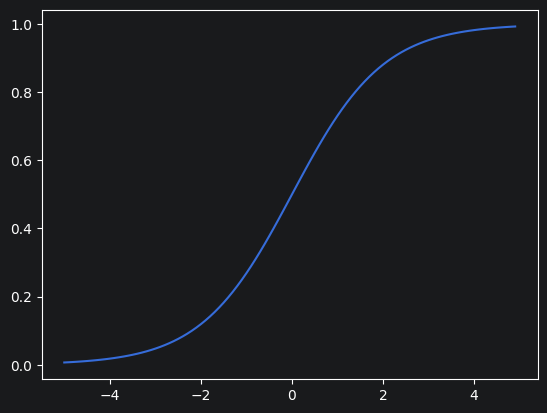

In [6]:
x = np.arange(-5,5,0.1)
y = sigmoid(x)
plt.plot(x, y)
plt.show()

## 阶跃函数

$$
h(x) =
\begin{cases}
0 & (x \le 0) \\
1 & (x > 0)
\end{cases}
$$

In [13]:
def step_function(x):
    # 这种写法无法传递数组
    # if x >= 0:
    #     return 1
    # else:
    #     return 0
    y = x>0
    return y.astype(np.int32)

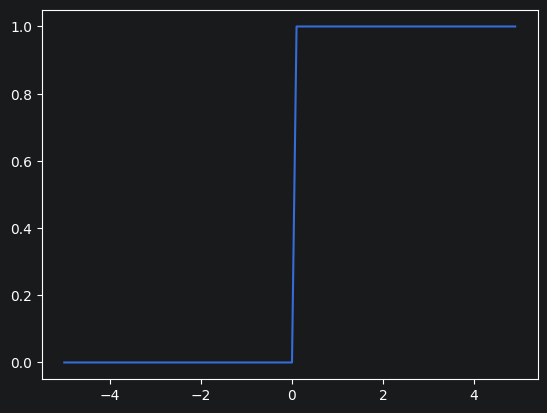

In [14]:
x = np.arange(-5,5,0.1)
y = step_function(x)
plt.plot(x, y)
plt.show()

## ReLU函数

rectified Linear Unit函数

$$
h(x) =
\begin{cases}
x & (x > 0) \\
0 & (x \le 0)
\end{cases}
$$

也可以写成：

$$h(x) = \max(0, x)$$

In [15]:
def relu(x):
    return np.maximum(0,x)

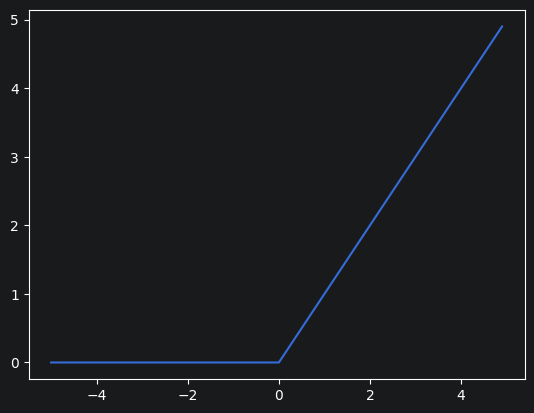

In [17]:
x = np.arange(-5,5,0.1)
y = relu(x)
plt.plot(x, y)
plt.show()

## Leaky ReLU函数

ReLU 的改进版，负区间给一个很小的斜率 $\alpha$（如 0.01），缓解神经元"死亡"问题。

$$
h(x) =
\begin{cases}
x & (x > 0) \\
\alpha x & (x \le 0)
\end{cases}
$$

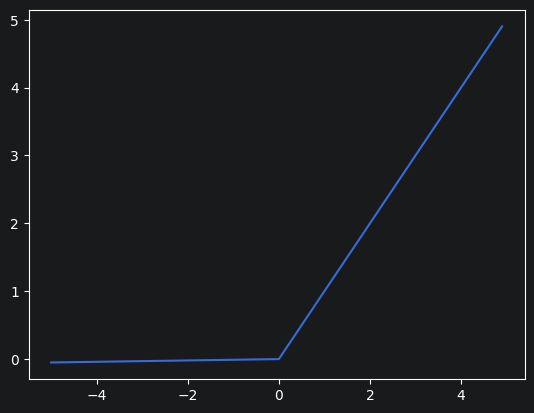

In [18]:
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)

x = np.arange(-5,5,0.1)
y = leaky_relu(x)
plt.plot(x, y)
plt.show()

## ELU函数

Exponential Linear Unit，负区间用指数曲线，输出更平滑，均值更接近 0。

$$
h(x) =
\begin{cases}
x & (x > 0) \\
\alpha\left(e^{x} - 1\right) & (x \le 0)
\end{cases}
$$

In [19]:
def elu(x, alpha=1.0):
    return np.where(x > 0, x, alpha * (np.exp(x) - 1))

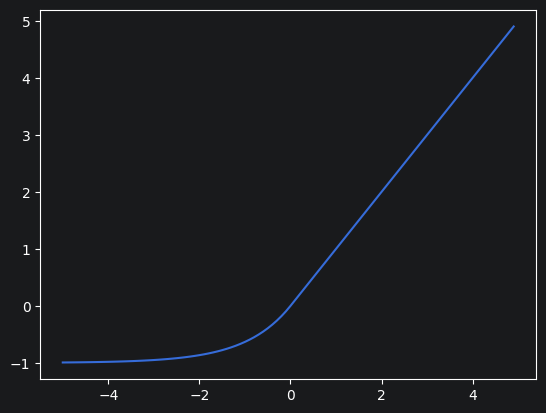

In [20]:
x = np.arange(-5,5,0.1)
y = elu(x)
plt.plot(x, y)
plt.show()

## GELU函数

Gaussian Error Linear Unit，BERT、GPT 等 Transformer 模型的默认激活函数。$\Phi(x)$ 为标准正态分布的累积分布函数。

$$\text{GELU}(x) = x \cdot \Phi(x)$$

常用 tanh 近似：

$$\text{GELU}(x) \approx 0.5\,x\left(1 + \tanh\left[\sqrt{\tfrac{2}{\pi}}\left(x + 0.044715\,x^3\right)\right]\right)$$

In [21]:
def gelu(x):
    # tanh 近似实现
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))

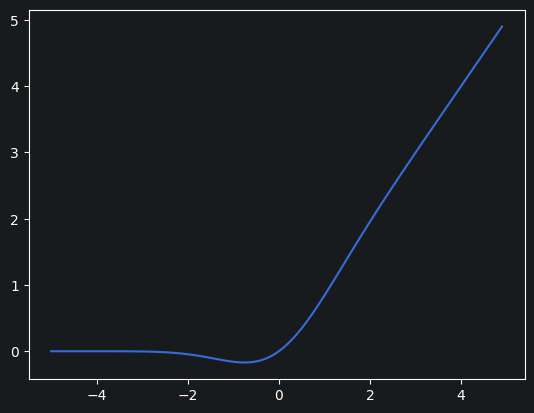

In [22]:
x = np.arange(-5,5,0.1)
y = gelu(x)
plt.plot(x, y)
plt.show()

## Swish函数 (SiLU)

平滑、非单调，深层网络中常优于 ReLU。

$$\text{Swish}(x) = x \cdot \sigma(x) = \frac{x}{1 + e^{-x}}$$

In [23]:
def swish(x):
    return x / (1 + np.exp(-x))

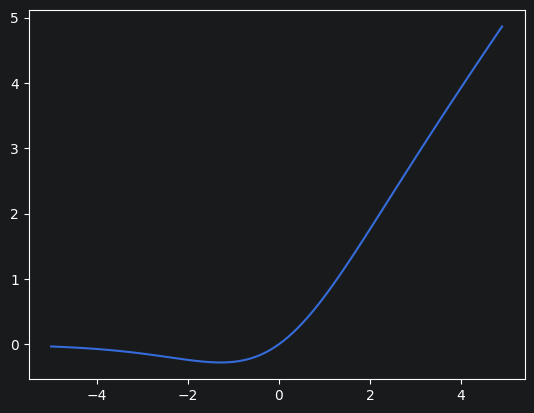

In [24]:
x = np.arange(-5,5,0.1)
y = swish(x)
plt.plot(x, y)
plt.show()

## softmax函数

常用于多分类网络的输出层，把一组实数转成和为 1 的概率分布。

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}$$

In [29]:
def softmax(x):
    c = np.max(x)            # 减去最大值，防止指数溢出
    exp_x = np.exp(x - c)
    return exp_x / np.sum(exp_x)

print(softmax(np.array([0.3, 2.9, 4.0])))
print(np.sum(softmax(np.array([0.3, 2.9, 4.0]))))  # 概率之和为 1

# 结果解读：
# 方式 1：y[0]的概率是 18%，y[1]的概率是 24.5%，...
# 方式 2：因为y[2]的概率最高，所以答案是 y[2]所对应的类别
# 方式 3：有 74% 的概率是 y[2]对应的类别，有 25%的概率是 y[1]对应的类别，...

[0.01821127 0.24519181 0.73659691]
1.0


In [ ]:
x = np.arange(-5,5,0.1)
y = softmax(x)
plt.plot(x, y)
plt.show()

## tanh函数

双曲正切，sigmoid 的"零中心"版本，输出范围 $(-1, 1)$。

$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$

In [27]:
def tanh(x):
    return np.tanh(x)

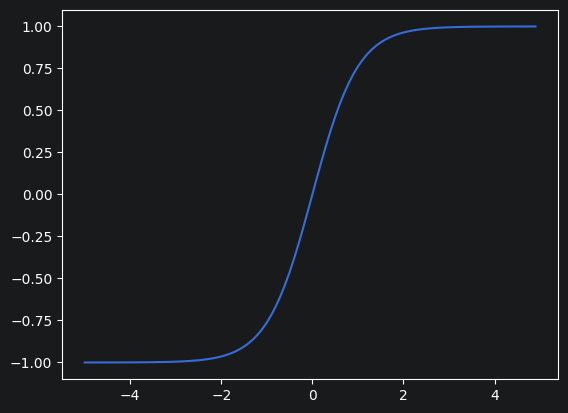

In [28]:
x = np.arange(-5,5,0.1)
y = tanh(x)
plt.plot(x, y)
plt.show()